# 04 — Modeling: retention_d7

Эксперимент по выбору модели и гиперпараметров для прогнозирования метрики **retention_d7** на двух приложениях (Flood-It! и Flood-It! 2). Все решения принимаются ТОЛЬКО на обучающей выборке (без leakage); результат сохраняется в `results/final_config.json`.

## 0. Контекст

**Таргет:** retention_d7 = доля пользователей, вернувшихся на 7-й день, диапазон [0, 1].

**Особенности:**
- Возможны нулевые значения → MAPE неприменима, используем MASE.
- ACF lag-1 ≈ 0.85 → значимая автокорреляция → CV = TimeSeriesSplit(5).
- Ожидаем низкий R² (метрика принципиально шумная при малой выборке).

**Гипотезы:**
- AR(1) baseline даст разумный пол; цель — обыграть его.
- NW(Gaussian) может проиграть из-за курса размерности при d=15.

In [1]:
import sys
from pathlib import Path

# Корень проекта в sys.path
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import warnings
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import Ridge, ElasticNet, ElasticNetCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import KFold, TimeSeriesSplit
from sklearn.metrics import mean_squared_error
from xgboost import XGBRegressor

from src.feature_engineering import load_dataset, select_features as select_leaky
from src.kernel_regression import NadarayaWatsonRegressor, LocalLinearRegressor
from src.evaluation import compute_regression_metrics, diebold_mariano_test
from notebooks._common import (
    APP_PALETTE, FIGSIZE_DEFAULT, FIGSIZE_WIDE,
    save_figure, theme_setup, app_label,
    chronological_split, select_features_clean, build_xy,
    fit_predict_evaluate, update_final_config,
    DEFAULT_OPERATIONAL_WHITELIST,
)

theme_setup()
np.random.seed(42)

TARGET = "retention_d7"
NOTEBOOK_SLUG = f"04_modeling_{TARGET}"
APP_F1 = "com.labpixies.flood"
APP_F2 = "com.google.flood2"


In [2]:
# ── Конфигурация эксперимента (единственное место для редактирования при клонировании) ─────
D_GRID = [3, 5, 8, 10, 12, 15]
BW_GRID = np.logspace(-2, 1, 20)

# CV-стратегия: KFold(shuffle=True) для stickiness/dau; TimeSeriesSplit(5) для retention_d7
def make_cv():
    return TimeSeriesSplit(n_splits=5)

CV_STRATEGY_LABEL = 'TimeSeriesSplit(5)'


## 1. Загрузка и валидация

Sanity-проверки: даты отсортированы внутри каждого app_id, target не весь NaN, оба ожидаемых app_id присутствуют.

In [3]:
df = load_dataset()
print(f"Размер датасета: {df.shape}")

# Проверки
assert {APP_F1, APP_F2}.issubset(df["app_id"].unique()), "Не все app_id найдены"
for app in [APP_F1, APP_F2]:
    sub = df[df["app_id"] == app].sort_values("date")
    assert sub["date"].is_monotonic_increasing, f"date не монотонна для {app}"
assert df[TARGET].notna().sum() >= 100, f"Слишком мало непустых {TARGET}"

print(f"app_id уникальные: {df['app_id'].unique().tolist()}")
print(f"Период: {df['date'].min()} — {df['date'].max()}")
print(f"Не-NaN {TARGET}: {df[TARGET].notna().sum()}")


Размер датасета: (222, 60)
app_id уникальные: ['com.google.flood2', 'com.labpixies.flood']
Период: 2018-06-12 00:00:00 — 2018-09-30 00:00:00
Не-NaN retention_d7: 119


## 2. Per-app split (хронологический 80/20)

Делим каждое приложение на train (первые 80% дней) и test (последние 20%). Все дальнейшие решения принимаются ТОЛЬКО на train; test трогается лишь в финальной оценке (секция 7).

In [4]:
df_f1 = df[df["app_id"] == APP_F1].sort_values("date").reset_index(drop=True)
df_f2 = df[df["app_id"] == APP_F2].sort_values("date").reset_index(drop=True)

df_tr_f1, df_te_f1 = chronological_split(df_f1, test_frac=0.2)
df_tr_f2, df_te_f2 = chronological_split(df_f2, test_frac=0.2)

split_summary = pd.DataFrame([
    {"app": "f1 (Flood-It!)",
     "n_train": len(df_tr_f1), "n_test": len(df_te_f1),
     "train_period": f"{df_tr_f1['date'].min().date()} — {df_tr_f1['date'].max().date()}",
     "test_period":  f"{df_te_f1['date'].min().date()} — {df_te_f1['date'].max().date()}"},
    {"app": "f2 (Flood-It! 2)",
     "n_train": len(df_tr_f2), "n_test": len(df_te_f2),
     "train_period": f"{df_tr_f2['date'].min().date()} — {df_tr_f2['date'].max().date()}",
     "test_period":  f"{df_te_f2['date'].min().date()} — {df_te_f2['date'].max().date()}"},
])
print(split_summary.to_string(index=False))


             app  n_train  n_test            train_period             test_period
  f1 (Flood-It!)       88      23 2018-06-12 — 2018-09-07 2018-09-08 — 2018-09-30
f2 (Flood-It! 2)       88      23 2018-06-12 — 2018-09-07 2018-09-08 — 2018-09-30


## 3. Демонстрация leakage (педагогический раздел)

Сравниваем два набора признаков:
- **LEAKY**: `src.feature_engineering.select_features` запущен на ПОЛНОМ df_f1 — видит test внутри (как в текущем pipeline).
- **CLEAN**: `select_features_clean` запущен ТОЛЬКО на df_tr_f1.

Финальная NW(d=15) обучается на одинаковом train, оценивается на одинаковом test, разница только в наборе признаков. Дельта R²/RMSE — оценка leakage-bias.

In [5]:
def _leakage_compare(df_full, df_train, df_test, app_label_str):
    # Получаем leaky-имена признаков (но не X/y — те leaky по построению)
    _, _, fnames_leaky = select_leaky(df_full, target=TARGET, max_features=15)
    # Получаем clean-имена признаков (только на train)
    fnames_clean = select_features_clean(df_train, target=TARGET, max_features=15)

    # ОДИН И ТОТ ЖЕ split, разница только в наборе признаков
    def _eval_with_features(fnames):
        X_tr, y_tr, medians = build_xy(df_train, TARGET, fnames)
        X_te, y_te, _ = build_xy(df_test, TARGET, fnames, train_medians=medians)
        sc = StandardScaler().fit(X_tr)
        nw = NadarayaWatsonRegressor(kernel='gaussian', bandwidth=1.0)
        nw.fit(sc.transform(X_tr), y_tr)
        pred = nw.predict(sc.transform(X_te))
        return compute_regression_metrics(y_pred=pred, y_true=y_te,
                                          target_name=TARGET, y_train=y_tr)

    metrics_l = _eval_with_features(fnames_leaky)
    metrics_c = _eval_with_features(fnames_clean)

    jaccard = (len(set(fnames_leaky) & set(fnames_clean)) /
               len(set(fnames_leaky) | set(fnames_clean)))
    return {
        'app': app_label_str,
        'jaccard_features': round(jaccard, 3),
        'leaky_R2':   round(metrics_l['r2'], 4),
        'clean_R2':   round(metrics_c['r2'], 4),
        'delta_R2':   round(metrics_l['r2'] - metrics_c['r2'], 4),
        'leaky_RMSE': round(metrics_l['rmse'], 5),
        'clean_RMSE': round(metrics_c['rmse'], 5),
        # СОХРАНИМ unrounded для C2-фикса в _build_decision
        '_unrounded_delta_r2':   metrics_l['r2'] - metrics_c['r2'],
        '_unrounded_delta_rmse': metrics_l['rmse'] - metrics_c['rmse'],
    }, fnames_leaky, fnames_clean

leakage_f1, fnames_leaky_f1, fnames_clean_f1 = _leakage_compare(df_f1, df_tr_f1, df_te_f1, 'f1')
leakage_f2, fnames_leaky_f2, fnames_clean_f2 = _leakage_compare(df_f2, df_tr_f2, df_te_f2, 'f2')

leakage_df = pd.DataFrame([
    {k: v for k, v in row.items() if not k.startswith('_')}
    for row in [leakage_f1, leakage_f2]
])
print(leakage_df.to_string(index=False))

print('\nf1 leaky-only features:', set(fnames_leaky_f1) - set(fnames_clean_f1))
print('f1 clean-only features:', set(fnames_clean_f1) - set(fnames_leaky_f1))


C:\Users\Анастасия\AppData\Roaming\Python\Python312\site-packages\pandas\core\nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)
C:\Users\Анастасия\AppData\Roaming\Python\Python312\site-packages\pandas\core\nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


app  jaccard_features  leaky_R2  clean_R2  delta_R2  leaky_RMSE  clean_RMSE
 f1             0.867    0.6819    0.6687    0.0132     0.03309     0.03377
 f2             0.636    0.6219    0.5438    0.0782     0.03680     0.04042

f1 leaky-only features: {'rating_trend', 'media_coverage_change'}
f1 clean-only features: set()


C:\Users\Анастасия\AppData\Roaming\Python\Python312\site-packages\pandas\core\nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)
C:\Users\Анастасия\AppData\Roaming\Python\Python312\site-packages\pandas\core\nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


## 4. Кривая d → CV-RMSE для NW

Для каждого d ∈ {3, 5, 8, 10, 12, 15}:
1. Отбираем d признаков на train.
2. Подбираем bandwidth через CV на train.
3. Вычисляем CV-RMSE с этим bandwidth.

Выбор d* по 1-SE rule: минимум CV-RMSE + 1·std → берём наименьшее d, попадающее под этот порог.

In [6]:
def _d_sweep(df_train, app_label_str):
    cv = make_cv()
    rows = []
    for d in D_GRID:
        fnames = select_features_clean(df_train, target=TARGET, max_features=d)
        X_tr, y_tr, _ = build_xy(df_train, TARGET, fnames)
        sc = StandardScaler().fit(X_tr)
        X_tr_sc = sc.transform(X_tr)

        # Подбор bw на этом наборе d признаков
        nw = NadarayaWatsonRegressor(kernel="gaussian", bandwidth=1.0)
        bw_optimal = nw.bandwidth_cv(X_tr_sc, y_tr, cv=cv, bandwidths=BW_GRID,
                                     random_state=42)

        # CV-RMSE с зафиксированным bw
        scores = []
        for tr_idx, va_idx in cv.split(X_tr_sc):
            m = NadarayaWatsonRegressor(kernel="gaussian", bandwidth=bw_optimal)
            m.fit(X_tr_sc[tr_idx], y_tr[tr_idx])
            pred = m.predict(X_tr_sc[va_idx])
            scores.append(np.sqrt(mean_squared_error(y_tr[va_idx], pred)))
        rows.append({
            "d": d, "bw": round(bw_optimal, 4),
            "rmse_mean": float(np.mean(scores)),
            "rmse_std": float(np.std(scores)),
            "fnames": fnames,
        })
    df_curve = pd.DataFrame(rows)
    df_curve["app"] = app_label_str
    return df_curve

curve_f1 = _d_sweep(df_tr_f1, "f1")
curve_f2 = _d_sweep(df_tr_f2, "f2")
curve_full = pd.concat([curve_f1, curve_f2], ignore_index=True)
print(curve_full.drop(columns=["fnames"]).to_string(index=False))


C:\Users\Анастасия\AppData\Roaming\Python\Python312\site-packages\pandas\core\nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


C:\7 семестр\пиздец\src\kernel_regression.py:251: RuntimeWarning: invalid value encountered in divide
  (weights @ self.y_train_) / weight_sums,
C:\Users\Анастасия\AppData\Roaming\Python\Python312\site-packages\pandas\core\nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


C:\7 семестр\пиздец\src\kernel_regression.py:251: RuntimeWarning: invalid value encountered in divide
  (weights @ self.y_train_) / weight_sums,
C:\Users\Анастасия\AppData\Roaming\Python\Python312\site-packages\pandas\core\nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


C:\7 семестр\пиздец\src\kernel_regression.py:251: RuntimeWarning: invalid value encountered in divide
  (weights @ self.y_train_) / weight_sums,
C:\Users\Анастасия\AppData\Roaming\Python\Python312\site-packages\pandas\core\nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


C:\7 семестр\пиздец\src\kernel_regression.py:251: RuntimeWarning: invalid value encountered in divide
  (weights @ self.y_train_) / weight_sums,
C:\Users\Анастасия\AppData\Roaming\Python\Python312\site-packages\pandas\core\nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


...

C:\7 семестр\пиздец\src\kernel_regression.py:251: RuntimeWarning: invalid value encountered in divide
  (weights @ self.y_train_) / weight_sums,
C:\Users\Анастасия\AppData\Roaming\Python\Python312\site-packages\pandas\core\nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


C:\7 семестр\пиздец\src\kernel_regression.py:251: RuntimeWarning: invalid value encountered in divide
  (weights @ self.y_train_) / weight_sums,
C:\Users\Анастасия\AppData\Roaming\Python\Python312\site-packages\pandas\core\nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)
C:\7 семестр\пиздец\src\kernel_regression.py:251: RuntimeWarning: invalid value encountered in divide
  (weights @ self.y_train_) / weight_sums,
C:\Users\Анастасия\AppData\Roaming\Python\Python312\site-packages\pandas\core\nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)
C:\7 семестр\пиздец\src\kernel_regression.py:251: RuntimeWarning: invalid value encountered in divide
  (weights @ self.y_train_) / weight_sums,


C:\Users\Анастасия\AppData\Roaming\Python\Python312\site-packages\pandas\core\nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


 d     bw  rmse_mean  rmse_std app
 3 0.7848   0.036206  0.006138  f1
 5 2.3357   0.041659  0.005739  f1
 8 2.3357   0.041693  0.006245  f1
10 2.3357   0.041957  0.006168  f1
12 2.3357   0.041820  0.005929  f1
15 2.3357   0.041692  0.005899  f1
 3 0.1833   0.055401  0.014992  f2
 5 0.1833   0.060627  0.008422  f2
 8 0.1833   0.061560  0.006654  f2
10 0.1833   0.061560  0.006654  f2
12 0.1833   0.061560  0.006654  f2
15 0.1833   0.061560  0.006654  f2


C:\7 семестр\пиздец\src\kernel_regression.py:251: RuntimeWarning: invalid value encountered in divide
  (weights @ self.y_train_) / weight_sums,


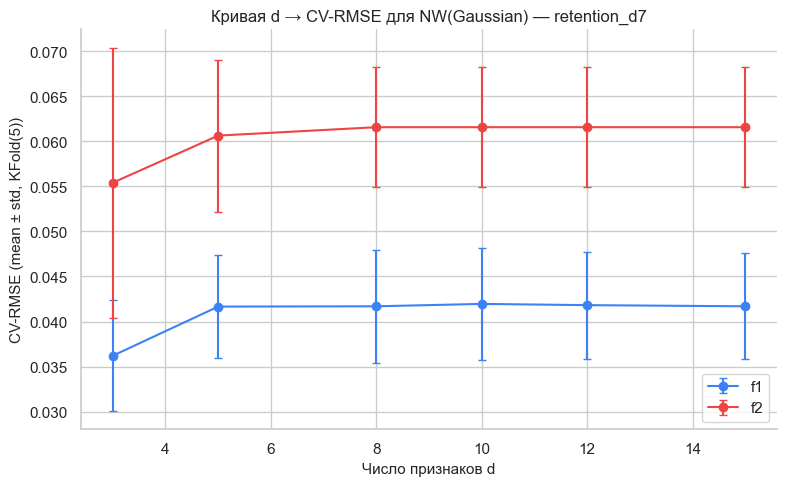

In [7]:
# График d → CV-RMSE
fig, ax = plt.subplots(figsize=FIGSIZE_DEFAULT)
for app_key, color in [("f1", APP_PALETTE[APP_F1]), ("f2", APP_PALETTE[APP_F2])]:
    sub = curve_full[curve_full["app"] == app_key]
    ax.errorbar(sub["d"], sub["rmse_mean"], yerr=sub["rmse_std"],
                marker="o", label=app_key, color=color, capsize=3)
ax.set_xlabel("Число признаков d")
ax.set_ylabel("CV-RMSE (mean ± std, KFold(5))")
ax.set_title(f"Кривая d → CV-RMSE для NW(Gaussian) — {TARGET}")
ax.legend()
plt.tight_layout()
save_figure("d_curve_nw", NOTEBOOK_SLUG)
plt.show()


In [8]:
# Выбор d* по 1-SE rule per app
def _pick_d_star(df_curve):
    best = df_curve.loc[df_curve["rmse_mean"].idxmin()]
    threshold = best["rmse_mean"] + best["rmse_std"]
    candidates = df_curve[df_curve["rmse_mean"] <= threshold].sort_values("d")
    chosen = candidates.iloc[0]
    return int(chosen["d"]), chosen["fnames"], float(chosen["bw"])

d_star_f1, fnames_d_f1, bw_d_f1 = _pick_d_star(curve_f1)
d_star_f2, fnames_d_f2, bw_d_f2 = _pick_d_star(curve_f2)
print(f"d* f1 = {d_star_f1} (bw={bw_d_f1}), признаки: {fnames_d_f1}")
print(f"d* f2 = {d_star_f2} (bw={bw_d_f2}), признаки: {fnames_d_f2}")


d* f1 = 3 (bw=0.7848), признаки: ['retention_trend', 'dau_growth_rate', 'onboarding_completion_rate', 'crash_rate', 'median_session_duration']
d* f2 = 3 (bw=0.1833), признаки: ['retention_trend', 'peak_hour', 'avg_session_duration', 'crash_rate', 'onboarding_completion_rate']


## 5. Sweep моделей при d = d*

Для каждого приложения сравниваем 7 моделей на CV-RMSE (KFold(5, shuffle=True, seed=42)):
- **Локальные:** NadarayaWatson, LocalLinear, kNN (k подобран на train)
- **Линейные:** Ridge(α=1), ElasticNet (α, l1 через ElasticNetCV)
- **Деревянные:** RandomForest(100), XGBoost(100, depth=4)

Победитель по минимуму CV-RMSE.

In [9]:
def _knn_optimal_k(X, y, cv):
    from sklearn.metrics import mean_squared_error as _mse
    # Вычислить минимальный размер обучающего фолда
    min_fold_train = min(len(tr_idx) for tr_idx, _ in cv.split(X))
    # k=3 включён в retention_d7 (не в stickiness/dau): для f2 после фильтрации NaN
    # train сокращается до ~36 строк, и при TimeSeriesSplit(5) первый fold имеет ~6
    # train-точек — даже k=5 на грани, k=3 безопаснее.
    candidates = [k for k in [3, 5, 10] if k <= min_fold_train]
    if not candidates:
        candidates = [max(1, min_fold_train)]
    best_k, best_rmse = candidates[0], np.inf
    for k in candidates:
        scores = []
        for tr_idx, va_idx in cv.split(X):
            m = KNeighborsRegressor(n_neighbors=k)
            m.fit(X[tr_idx], y[tr_idx])
            scores.append(np.sqrt(_mse(y[va_idx], m.predict(X[va_idx]))))
        rmse = float(np.mean(scores))
        if rmse < best_rmse:
            best_k, best_rmse = k, rmse
    return best_k

def _model_sweep(df_train, df_test, fnames, bw_nw, app_label_str):
    cv = make_cv()
    X_tr, y_tr, medians = build_xy(df_train, TARGET, fnames)
    X_te, y_te, _ = build_xy(df_test, TARGET, fnames, train_medians=medians)
    sc = StandardScaler().fit(X_tr)
    X_tr_sc = sc.transform(X_tr)
    X_te_sc = sc.transform(X_te)

    # Подбор bw для LocalLinear (отдельно от NW)
    ll_tmp = LocalLinearRegressor(kernel="gaussian", bandwidth=1.0)
    bw_ll = ll_tmp.bandwidth_cv(X_tr_sc, y_tr, cv=cv, bandwidths=BW_GRID, random_state=42)

    # Подбор k для kNN
    k_opt = _knn_optimal_k(X_tr_sc, y_tr, cv)

    # ElasticNetCV ищет (alpha, l1_ratio) сам
    en_cv = ElasticNetCV(l1_ratio=[0.1, 0.5, 0.7, 0.9, 0.95, 0.99],
                         alphas=np.logspace(-3, 1, 30),
                         cv=5, random_state=42, n_jobs=1, max_iter=20000)
    en_cv.fit(X_tr_sc, y_tr)
    en_alpha, en_l1 = float(en_cv.alpha_), float(en_cv.l1_ratio_)

    # Внимание: этот dict интенционально использует индивидуальные lambda-функции.
    # НЕ преобразовывать в for-цикл без default-arg binding (lambda x=x: ...) —
    # late-binding в Python даст одинаковые замыкания.
    factories = {
        "NadarayaWatson":  lambda: NadarayaWatsonRegressor(kernel="gaussian", bandwidth=bw_nw),
        "LocalLinear":     lambda: LocalLinearRegressor(kernel="gaussian", bandwidth=bw_ll),
        "kNN":             lambda: KNeighborsRegressor(n_neighbors=k_opt),
        "Ridge":           lambda: Ridge(alpha=1.0, random_state=42),
        "ElasticNet":      lambda: ElasticNet(alpha=en_alpha, l1_ratio=en_l1,
                                               random_state=42, max_iter=20000),
        "RandomForest":    lambda: RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=1),
        "XGBoost":         lambda: XGBRegressor(n_estimators=100, max_depth=4, learning_rate=0.1,
                                                 random_state=42, verbosity=0),
    }

    rows = []
    detailed = {}
    for name, factory in factories.items():
        res = fit_predict_evaluate(
            factory, X_tr_sc, y_tr, X_te_sc, y_te,
            target_name=TARGET, cv=cv,
        )
        rows.append({
            "model": name,
            "cv_rmse_mean": round(res["cv_rmse_mean"], 5),
            "cv_rmse_std":  round(res["cv_rmse_std"], 5),
            "test_rmse":    round(res["test_metrics"]["rmse"], 5),
            "test_r2":      round(res["test_metrics"]["r2"], 4),
        })
        detailed[name] = res

    sweep_df = pd.DataFrame(rows).sort_values("cv_rmse_mean").reset_index(drop=True)
    sweep_df["app"] = app_label_str
    extra = {"bw_nw": bw_nw, "bw_ll": bw_ll, "k_opt": k_opt,
             "en_alpha": en_alpha, "en_l1": en_l1, "medians": medians,
             "X_tr_sc": X_tr_sc, "X_te_sc": X_te_sc, "y_tr": y_tr, "y_te": y_te,
             "scaler": sc}
    return sweep_df, detailed, extra

sweep_f1, detailed_f1, extra_f1 = _model_sweep(df_tr_f1, df_te_f1, fnames_d_f1, bw_d_f1, "f1")
sweep_f2, detailed_f2, extra_f2 = _model_sweep(df_tr_f2, df_te_f2, fnames_d_f2, bw_d_f2, "f2")

print("=== f1 Flood-It! ===")
print(sweep_f1.to_string(index=False))
print("\n=== f2 Flood-It! 2 ===")
print(sweep_f2.to_string(index=False))


=== f1 Flood-It! ===
         model  cv_rmse_mean  cv_rmse_std  test_rmse  test_r2 app
         Ridge       0.03272      0.00349    0.03519   0.6404  f1
   LocalLinear       0.03282      0.00588    0.02949   0.7474  f1
    ElasticNet       0.03285      0.00395    0.02546   0.8117  f1
  RandomForest       0.03574      0.00361    0.02862   0.7621  f1
NadarayaWatson       0.03621      0.00614    0.02800   0.7723  f1
       XGBoost       0.03795      0.00432    0.02227   0.8559  f1
           kNN       0.03963      0.00722    0.03297   0.6843  f1

=== f2 Flood-It! 2 ===
         model  cv_rmse_mean  cv_rmse_std  test_rmse  test_r2 app
NadarayaWatson       0.05540      0.01499    0.06670  -0.2420  f2
  RandomForest       0.06002      0.01038    0.04771   0.3645  f2
    ElasticNet       0.06050      0.01036    0.04711   0.3803  f2
       XGBoost       0.06375      0.01374    0.05909   0.0252  f2
           kNN       0.06379      0.01103    0.04170   0.5146  f2
   LocalLinear       0.06445   

## 5b. AR(1) baseline через statsmodels

ARIMA(p=1, d=0, q=0) — обучается на y_train (без признаков), делает многошаговый прогноз на длину test. Это «честный пол» для временных рядов — NW обязана его обыграть.

In [10]:
from statsmodels.tsa.arima.model import ARIMA

def _ar1_evaluate(y_tr, y_te, cv):
    scores = []
    for tr_idx, va_idx in cv.split(y_tr):
        if len(tr_idx) < 5:
            continue
        try:
            m = ARIMA(y_tr[tr_idx], order=(1, 0, 0)).fit()
            pred = m.forecast(steps=len(va_idx))
            scores.append(float(np.sqrt(mean_squared_error(y_tr[va_idx], pred))))
        except Exception as e:
            print(f'AR(1) CV fold пропущен: {e}')
    cv_rmse_mean = float(np.mean(scores)) if scores else float('nan')
    cv_rmse_std  = float(np.std(scores)) if scores else 0.0

    final = ARIMA(y_tr, order=(1, 0, 0)).fit()
    y_pred = np.asarray(final.forecast(steps=len(y_te)), dtype=float)
    test_metrics = compute_regression_metrics(
        y_pred=y_pred, y_true=y_te,
        target_name=TARGET, y_train=y_tr,
    )
    return {
        'model': final,
        'cv_rmse_mean': cv_rmse_mean,
        'cv_rmse_std':  cv_rmse_std,
        'test_metrics': test_metrics,
        'y_pred': y_pred.tolist(),
        'summary': str(final.summary()),
    }

cv_ts = make_cv()
ar1_f1 = _ar1_evaluate(extra_f1['y_tr'], extra_f1['y_te'], cv_ts)
ar1_f2 = _ar1_evaluate(extra_f2['y_tr'], extra_f2['y_te'], cv_ts)

print('=== AR(1) f1 ===')
print(f"CV-RMSE = {ar1_f1['cv_rmse_mean']:.5f} ± {ar1_f1['cv_rmse_std']:.5f}")
print(f"Test metrics: {ar1_f1['test_metrics']}")
print('\\n=== AR(1) f2 ===')
print(f"CV-RMSE = {ar1_f2['cv_rmse_mean']:.5f} ± {ar1_f2['cv_rmse_std']:.5f}")
print(f"Test metrics: {ar1_f2['test_metrics']}")


=== AR(1) f1 ===
CV-RMSE = 0.04440 ± 0.00548
Test metrics: {'rmse': 0.05879970307765113, 'mae': 0.04301688948529111, 'mape': 58.34656686554449, 'smape': 48.78589680061488, 'r2': -0.004247750010750284, 'mase': 0.8970707988254513}
\n=== AR(1) f2 ===
CV-RMSE = 0.06649 ± 0.00379
Test metrics: {'rmse': 0.06153057970491976, 'mae': 0.057888378795591, 'mape': 85.74861015641349, 'smape': 55.304187272161506, 'r2': -0.05699879641635275, 'mase': 0.89898132575846}


In [11]:
def _append_ar1(sweep_df, ar1_res):
    new_row = {
        'model': 'AR(1)',
        'cv_rmse_mean': round(ar1_res['cv_rmse_mean'], 5),
        'cv_rmse_std':  round(ar1_res['cv_rmse_std'], 5),
        'test_rmse':    round(ar1_res['test_metrics']['rmse'], 5),
        'test_r2':      round(ar1_res['test_metrics']['r2'], 4),
        'app':          sweep_df['app'].iloc[0],
    }
    return pd.concat([sweep_df, pd.DataFrame([new_row])], ignore_index=True)\
        .sort_values('cv_rmse_mean').reset_index(drop=True)

sweep_f1 = _append_ar1(sweep_f1, ar1_f1)
sweep_f2 = _append_ar1(sweep_f2, ar1_f2)

# Добавляем в detailed для возможных последующих сравнений
detailed_f1['AR(1)'] = ar1_f1
detailed_f2['AR(1)'] = ar1_f2

print('=== f1 (включая AR(1)) ===')
print(sweep_f1.to_string(index=False))
print('\\n=== f2 (включая AR(1)) ===')
print(sweep_f2.to_string(index=False))


=== f1 (включая AR(1)) ===
         model  cv_rmse_mean  cv_rmse_std  test_rmse  test_r2 app
         Ridge       0.03272      0.00349    0.03519   0.6404  f1
   LocalLinear       0.03282      0.00588    0.02949   0.7474  f1
    ElasticNet       0.03285      0.00395    0.02546   0.8117  f1
  RandomForest       0.03574      0.00361    0.02862   0.7621  f1
NadarayaWatson       0.03621      0.00614    0.02800   0.7723  f1
       XGBoost       0.03795      0.00432    0.02227   0.8559  f1
           kNN       0.03963      0.00722    0.03297   0.6843  f1
         AR(1)       0.04440      0.00548    0.05880  -0.0042  f1
\n=== f2 (включая AR(1)) ===
         model  cv_rmse_mean  cv_rmse_std  test_rmse  test_r2 app
NadarayaWatson       0.05540      0.01499    0.06670  -0.2420  f2
  RandomForest       0.06002      0.01038    0.04771   0.3645  f2
    ElasticNet       0.06050      0.01036    0.04711   0.3803  f2
       XGBoost       0.06375      0.01374    0.05909   0.0252  f2
           kNN      

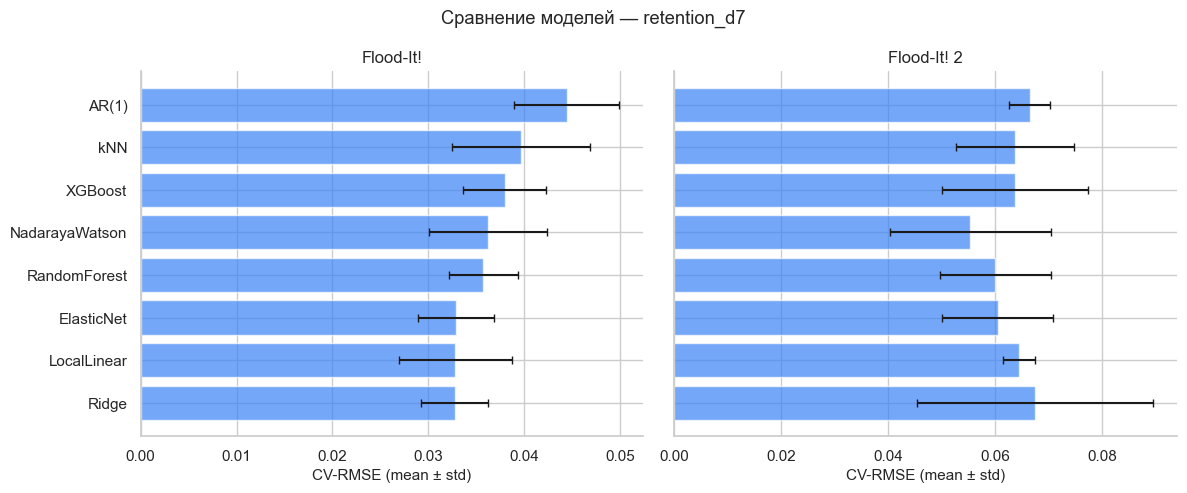

In [12]:
# Bar chart сравнения моделей
fig, axes = plt.subplots(1, 2, figsize=FIGSIZE_WIDE, sharey=True)
for ax, df_sweep, app_str in [(axes[0], sweep_f1, "Flood-It!"),
                              (axes[1], sweep_f2, "Flood-It! 2")]:
    ax.barh(df_sweep["model"], df_sweep["cv_rmse_mean"],
            xerr=df_sweep["cv_rmse_std"], color="#3b82f6", alpha=0.7, capsize=3)
    ax.set_xlabel("CV-RMSE (mean ± std)")
    ax.set_title(app_str)
    ax.invert_yaxis()
fig.suptitle(f"Сравнение моделей — {TARGET}")
plt.tight_layout()
save_figure("model_comparison", NOTEBOOK_SLUG)
plt.show()


## 6. Sweep ядер и bandwidth для NW

Делается всегда (даже если NW не победила в #5) — для отчёта и текста диплома. Heatmap kernel × bandwidth с CV-RMSE.

In [13]:
def _kernel_bw_heatmap(X_tr_sc, y_tr, app_label_str):
    cv = make_cv()
    kernels = ["gaussian", "epanechnikov", "triangular"]
    grid = np.logspace(-2, 1, 20)
    heatmap = np.full((len(kernels), len(grid)), np.nan)
    for i, kern in enumerate(kernels):
        for j, bw in enumerate(grid):
            scores = []
            for tr_idx, va_idx in cv.split(X_tr_sc):
                m = NadarayaWatsonRegressor(kernel=kern, bandwidth=bw)
                m.fit(X_tr_sc[tr_idx], y_tr[tr_idx])
                scores.append(np.sqrt(mean_squared_error(
                    y_tr[va_idx], m.predict(X_tr_sc[va_idx]))))
            heatmap[i, j] = float(np.mean(scores))
    best_idx = np.unravel_index(np.argmin(heatmap), heatmap.shape)
    return heatmap, kernels, grid, kernels[best_idx[0]], float(grid[best_idx[1]])

heat_f1, kernels, bw_grid, kernel_star_f1, bw_star_f1 = _kernel_bw_heatmap(
    extra_f1["X_tr_sc"], extra_f1["y_tr"], "f1")
heat_f2, _, _, kernel_star_f2, bw_star_f2 = _kernel_bw_heatmap(
    extra_f2["X_tr_sc"], extra_f2["y_tr"], "f2")

print(f"f1: kernel*={kernel_star_f1}, bw*={bw_star_f1:.4f}")
print(f"f2: kernel*={kernel_star_f2}, bw*={bw_star_f2:.4f}")


C:\7 семестр\пиздец\src\kernel_regression.py:251: RuntimeWarning: invalid value encountered in divide
  (weights @ self.y_train_) / weight_sums,
C:\7 семестр\пиздец\src\kernel_regression.py:251: RuntimeWarning: invalid value encountered in divide
  (weights @ self.y_train_) / weight_sums,
C:\7 семестр\пиздец\src\kernel_regression.py:251: RuntimeWarning: invalid value encountered in divide
  (weights @ self.y_train_) / weight_sums,
C:\7 семестр\пиздец\src\kernel_regression.py:251: RuntimeWarning: invalid value encountered in divide
  (weights @ self.y_train_) / weight_sums,
C:\7 семестр\пиздец\src\kernel_regression.py:251: RuntimeWarning: invalid value encountered in divide
  (weights @ self.y_train_) / weight_sums,
C:\7 семестр\пиздец\src\kernel_regression.py:251: RuntimeWarning: invalid value encountered in divide
  (weights @ self.y_train_) / weight_sums,
C:\7 семестр\пиздец\src\kernel_regression.py:251: RuntimeWarning: invalid value encountered in divide
  (weights @ self.y_train_) 

f1: kernel*=gaussian, bw*=0.7848
f2: kernel*=gaussian, bw*=0.1833


C:\7 семестр\пиздец\src\kernel_regression.py:251: RuntimeWarning: invalid value encountered in divide
  (weights @ self.y_train_) / weight_sums,
C:\7 семестр\пиздец\src\kernel_regression.py:251: RuntimeWarning: invalid value encountered in divide
  (weights @ self.y_train_) / weight_sums,
C:\7 семестр\пиздец\src\kernel_regression.py:251: RuntimeWarning: invalid value encountered in divide
  (weights @ self.y_train_) / weight_sums,
C:\7 семестр\пиздец\src\kernel_regression.py:251: RuntimeWarning: invalid value encountered in divide
  (weights @ self.y_train_) / weight_sums,
C:\7 семестр\пиздец\src\kernel_regression.py:251: RuntimeWarning: invalid value encountered in divide
  (weights @ self.y_train_) / weight_sums,
C:\7 семестр\пиздец\src\kernel_regression.py:251: RuntimeWarning: invalid value encountered in divide
  (weights @ self.y_train_) / weight_sums,
C:\7 семестр\пиздец\src\kernel_regression.py:251: RuntimeWarning: invalid value encountered in divide
  (weights @ self.y_train_) 

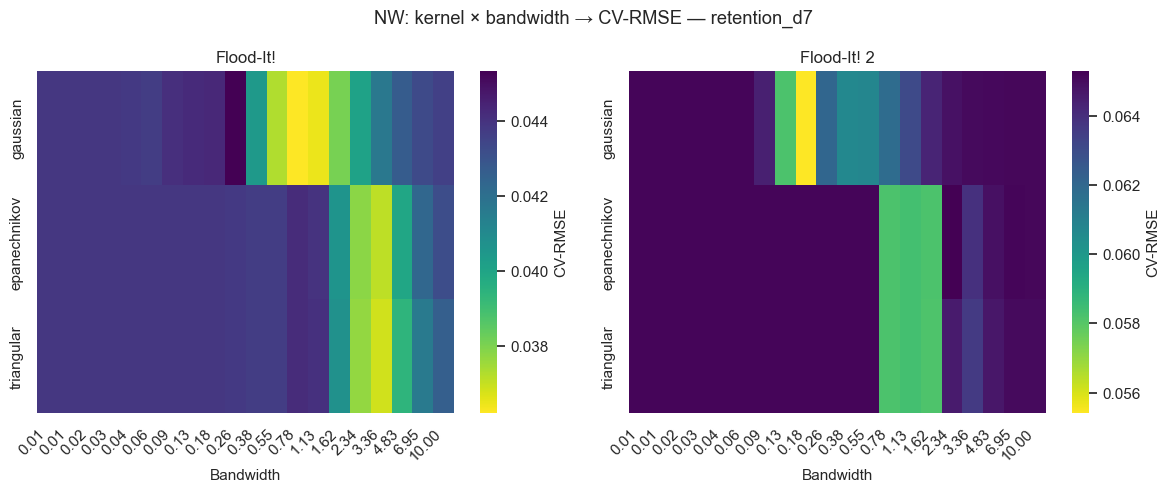

In [14]:
fig, axes = plt.subplots(1, 2, figsize=FIGSIZE_WIDE)
for ax, heat, app_str in [(axes[0], heat_f1, "Flood-It!"),
                          (axes[1], heat_f2, "Flood-It! 2")]:
    sns.heatmap(heat, ax=ax, xticklabels=[f"{b:.2f}" for b in bw_grid],
                yticklabels=kernels, cmap="viridis_r", cbar_kws={"label": "CV-RMSE"})
    ax.set_xlabel("Bandwidth")
    ax.set_title(app_str)
    for label in ax.get_xticklabels():
        label.set_rotation(45); label.set_ha("right")
fig.suptitle(f"NW: kernel × bandwidth → CV-RMSE — {TARGET}")
plt.tight_layout()
save_figure("bw_kernel_heatmap", NOTEBOOK_SLUG)
plt.show()


## 7. Финальный фит выбранной модели на TEST

Берём победителя из секции 5 (по CV-RMSE). Если победитель — NW/LocalLinear, обновляем (kernel, bandwidth) на оптимум из секции 6. DM-тест NW vs Ridge на остатках test.

In [15]:
def _final_fit(sweep_df, detailed, extra, kernel_star, bw_star):
    winner = sweep_df.iloc[0]["model"]

    # Если победил NW/LL — пересобираем с (kernel*, bw*)
    if winner == "NadarayaWatson":
        m = NadarayaWatsonRegressor(kernel=kernel_star, bandwidth=bw_star)
        m.fit(extra["X_tr_sc"], extra["y_tr"])
        y_pred = m.predict(extra["X_te_sc"])
    elif winner == "LocalLinear":
        m = LocalLinearRegressor(kernel=kernel_star, bandwidth=bw_star)
        m.fit(extra["X_tr_sc"], extra["y_tr"])
        y_pred = m.predict(extra["X_te_sc"])
    else:
        m = detailed[winner]["model"]
        y_pred = np.array(detailed[winner]["y_pred"])

    test_metrics = compute_regression_metrics(
        y_pred=y_pred, y_true=extra["y_te"],
        target_name=TARGET, y_train=extra["y_tr"],
    )

    # DM-тест NW vs Ridge
    err_nw = extra["y_te"] - np.array(detailed["NadarayaWatson"]["y_pred"])
    err_ridge = extra["y_te"] - np.array(detailed["Ridge"]["y_pred"])
    dm = diebold_mariano_test(err_nw, err_ridge)

    return winner, m, y_pred, test_metrics, dm

winner_f1, model_final_f1, ypred_f1, test_m_f1, dm_f1 = _final_fit(
    sweep_f1, detailed_f1, extra_f1, kernel_star_f1, bw_star_f1)
winner_f2, model_final_f2, ypred_f2, test_m_f2, dm_f2 = _final_fit(
    sweep_f2, detailed_f2, extra_f2, kernel_star_f2, bw_star_f2)

print(f"f1 winner: {winner_f1}; test metrics: {test_m_f1}")
print(f"f1 DM NW vs Ridge: stat={dm_f1['dm_stat']:.3f}, p={dm_f1['p_value']:.4f}")
print(f"\nf2 winner: {winner_f2}; test metrics: {test_m_f2}")
print(f"f2 DM NW vs Ridge: stat={dm_f2['dm_stat']:.3f}, p={dm_f2['p_value']:.4f}")


f1 winner: Ridge; test metrics: {'rmse': 0.0351876574927405, 'mae': 0.028573361045018404, 'mape': 57.91156263733388, 'smape': 64.09731217840566, 'r2': 0.6403572470607799, 'mase': 0.5958666031988953}
f1 DM NW vs Ridge: stat=-0.898, p=0.3692

f2 winner: NadarayaWatson; test metrics: {'rmse': 0.06669714537660068, 'mae': 0.06347621497970177, 'mape': 79.39856517421451, 'smape': 57.6627133053639, 'r2': -0.24195818056170415, 'mase': 0.9857579894935237}
f2 DM NW vs Ridge: stat=2.139, p=0.0325


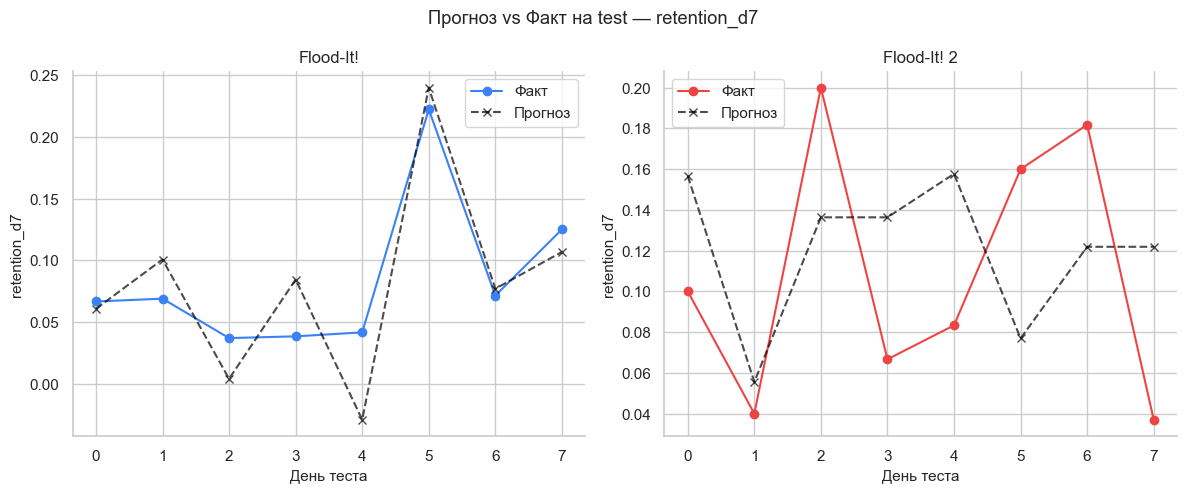

In [16]:
# Plot: факт vs прогноз для f1 и f2
fig, axes = plt.subplots(1, 2, figsize=FIGSIZE_WIDE)
for ax, ytr, yte, ypred, app_str, color in [
    (axes[0], extra_f1["y_tr"], extra_f1["y_te"], ypred_f1, "Flood-It!", APP_PALETTE[APP_F1]),
    (axes[1], extra_f2["y_tr"], extra_f2["y_te"], ypred_f2, "Flood-It! 2", APP_PALETTE[APP_F2]),
]:
    test_x = np.arange(len(yte))
    ax.plot(test_x, yte, "o-", color=color, label="Факт")
    ax.plot(test_x, ypred, "x--", color="black", label="Прогноз", alpha=0.7)
    ax.set_xlabel("День теста"); ax.set_ylabel(TARGET); ax.set_title(app_str); ax.legend()
fig.suptitle(f"Прогноз vs Факт на test — {TARGET}")
plt.tight_layout()
save_figure("prediction_vs_actual", NOTEBOOK_SLUG)
plt.show()


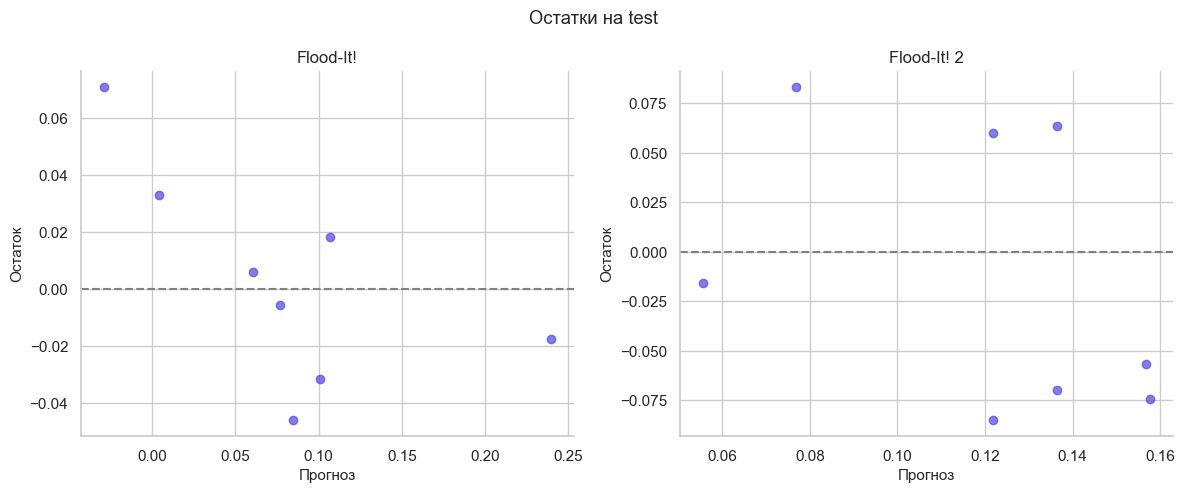

In [17]:
# Residuals scatter
fig, axes = plt.subplots(1, 2, figsize=FIGSIZE_WIDE)
for ax, yte, ypred, app_str in [
    (axes[0], extra_f1["y_te"], ypred_f1, "Flood-It!"),
    (axes[1], extra_f2["y_te"], ypred_f2, "Flood-It! 2"),
]:
    res = yte - ypred
    ax.scatter(ypred, res, color="#4f46e5", alpha=0.7)
    ax.axhline(0, color="gray", linestyle="--")
    ax.set_xlabel("Прогноз"); ax.set_ylabel("Остаток"); ax.set_title(app_str)
fig.suptitle("Остатки на test")
plt.tight_layout()
save_figure("residuals", NOTEBOOK_SLUG)
plt.show()


## 8. Диагностика остатков

Гистограмма остатков + QQ-plot + scatter residuals × каждый признак (топ-4 по permutation importance).

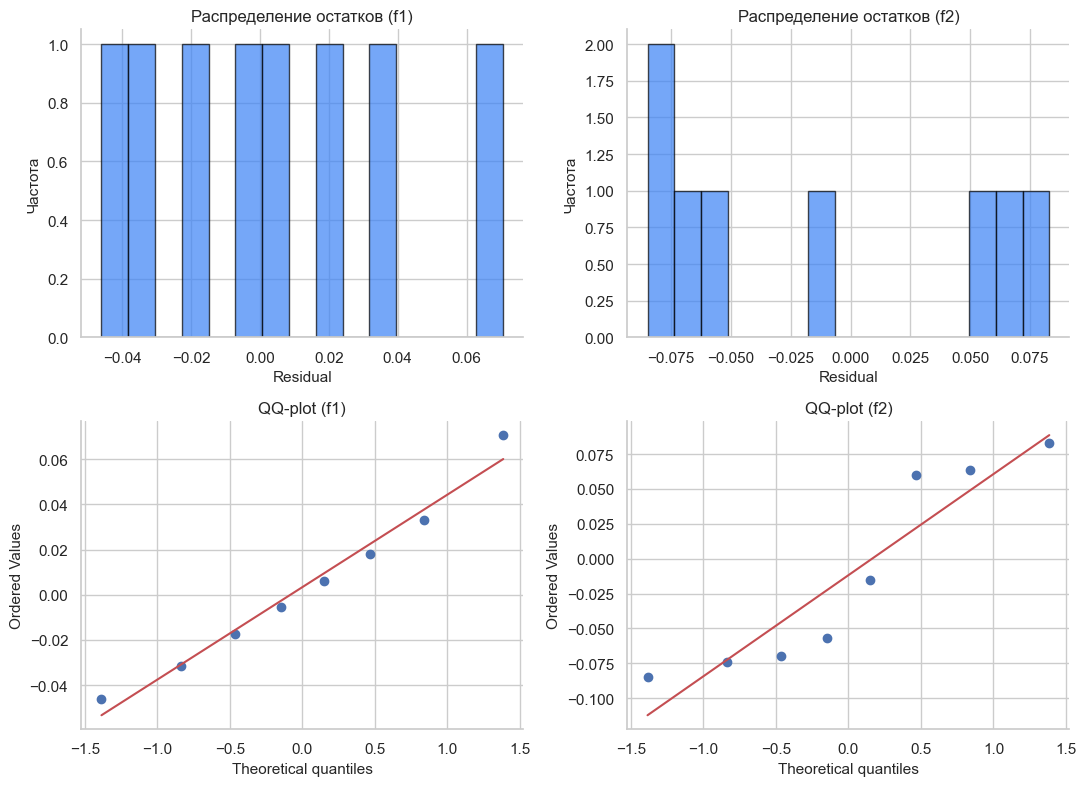

In [18]:
from scipy import stats as sp_stats

fig, axes = plt.subplots(2, 2, figsize=(11, 8))
for col_idx, (yte, ypred, app_str) in enumerate([
    (extra_f1["y_te"], ypred_f1, "f1"),
    (extra_f2["y_te"], ypred_f2, "f2"),
]):
    res = np.array(yte - ypred)
    axes[0, col_idx].hist(res, bins=15, color="#3b82f6", alpha=0.7, edgecolor="black")
    axes[0, col_idx].set_title(f"Распределение остатков ({app_str})")
    axes[0, col_idx].set_xlabel("Residual"); axes[0, col_idx].set_ylabel("Частота")

    sp_stats.probplot(res, dist="norm", plot=axes[1, col_idx])
    axes[1, col_idx].set_title(f"QQ-plot ({app_str})")
plt.tight_layout()
save_figure("residual_diagnostics", NOTEBOOK_SLUG)
plt.show()


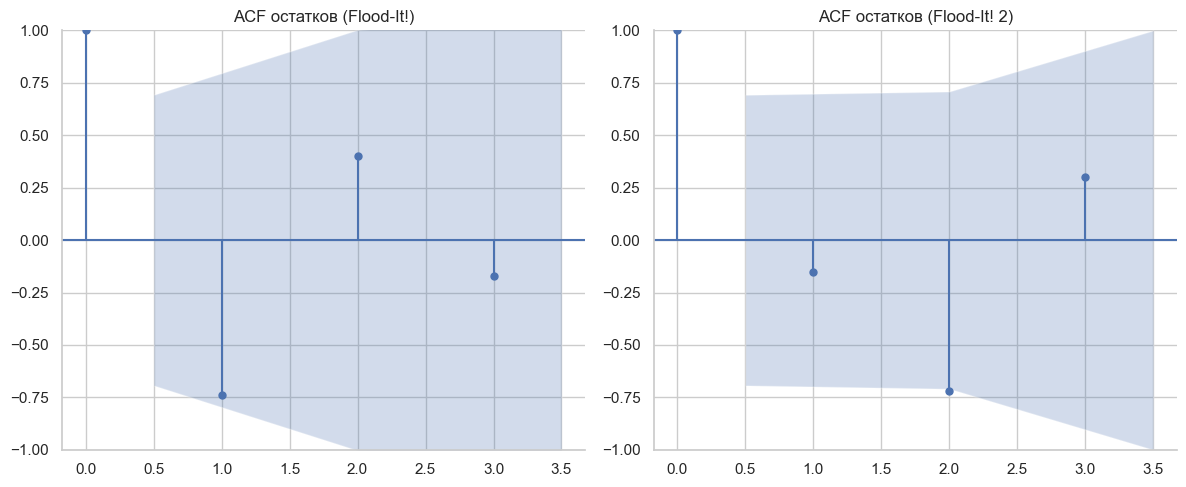

In [19]:
# ACF остатков — критично для retention_d7
from statsmodels.graphics.tsaplots import plot_acf

fig, axes = plt.subplots(1, 2, figsize=FIGSIZE_WIDE)
for ax, yte, ypred, app_str in [
    (axes[0], extra_f1['y_te'], ypred_f1, 'Flood-It!'),
    (axes[1], extra_f2['y_te'], ypred_f2, 'Flood-It! 2'),
]:
    res = np.array(yte - ypred)
    n_lags = min(10, len(res) // 2 - 1)
    plot_acf(res, lags=n_lags, ax=ax, title=f'ACF остатков ({app_str})')
plt.tight_layout()
save_figure('acf_residuals', NOTEBOOK_SLUG)
plt.show()


## 9. Сохранение решения в `results/final_config.json`

Для каждого приложения формируем decision-словарь по spec-схеме (раздел 7) и вызываем `update_final_config`.

In [20]:
def _build_decision(winner, fnames, medians, kernel_star, bw_star, sweep_df,
                    test_metrics, dm_result, leakage_row, k_opt, en_alpha, en_l1,
                    ar1_res=None):
    cv_row = sweep_df[sweep_df["model"] == winner].iloc[0]
    decision = {
        "model": winner,
        "kernel": kernel_star if winner in ("NadarayaWatson", "LocalLinear") else None,
        "bandwidth": bw_star if winner in ("NadarayaWatson", "LocalLinear") else None,
        "max_features": len(fnames),
        "features": list(fnames),
        "feature_train_medians": {k: float(v) for k, v in medians.items()},
        "test_metrics": {k: (float(v) if v is not None else None)
                         for k, v in test_metrics.items()},
        "cv_metrics": {
            "rmse_mean": float(cv_row["cv_rmse_mean"]),
            "rmse_std":  float(cv_row["cv_rmse_std"]),
            "n_folds": 5,
            "cv_strategy": CV_STRATEGY_LABEL,
        },
        "leakage_delta": {
            "r2_leaky_minus_clean":   round(float(leakage_row["_unrounded_delta_r2"]), 4),
            "rmse_leaky_minus_clean": round(float(leakage_row["_unrounded_delta_rmse"]), 5),
        },
        "dm_vs_ridge": {
            "dm_stat":  float(dm_result["dm_stat"]),
            "p_value":  float(dm_result["p_value"]),
            "winner":   dm_result["winner"],
        },
        "k_optimal_knn":     k_opt if winner == "kNN" else None,
        "elasticnet_params": {"alpha": en_alpha, "l1_ratio": en_l1} if winner == "ElasticNet" else None,
    }

    # Дополнительные поля для retention_d7 (AR(1) baseline)
    if ar1_res is not None:
        ar1_rmse = float(ar1_res["test_metrics"]["rmse"])
        winner_rmse = float(test_metrics["rmse"])
        delta = ar1_rmse - winner_rmse
        decision["ar1_baseline_rmse"] = ar1_rmse
        decision["winner_vs_ar1"] = (
            f"{winner} лучше AR(1) на ΔRMSE={delta:.5f}"
            if delta > 0 else
            f"AR(1) лучше {winner} на ΔRMSE={-delta:.5f}"
        )

    decision["operational_features"] = sorted(
        set(fnames) & set(DEFAULT_OPERATIONAL_WHITELIST)
    )
    return decision

decision_f1 = _build_decision(
    winner_f1, fnames_d_f1, extra_f1["medians"], kernel_star_f1, bw_star_f1,
    sweep_f1, test_m_f1, dm_f1, leakage_f1,
    extra_f1["k_opt"], extra_f1["en_alpha"], extra_f1["en_l1"],
    ar1_res=ar1_f1,
)
decision_f2 = _build_decision(
    winner_f2, fnames_d_f2, extra_f2["medians"], kernel_star_f2, bw_star_f2,
    sweep_f2, test_m_f2, dm_f2, leakage_f2,
    extra_f2["k_opt"], extra_f2["en_alpha"], extra_f2["en_l1"],
    ar1_res=ar1_f2,
)

update_final_config("f1", TARGET, decision_f1)
update_final_config("f2", TARGET, decision_f2)

# Подтверждаем запись
cfg_path = ROOT / "results" / "final_config.json"
config = json.loads(cfg_path.read_text(encoding="utf-8"))
print(f"Записано в {cfg_path}")
print(f"f1.{TARGET}: model={config['f1'][TARGET]['model']}, "
      f"d={config['f1'][TARGET]['max_features']}, "
      f"R²={config['f1'][TARGET]['test_metrics']['r2']:.3f}")
print(f"f2.{TARGET}: model={config['f2'][TARGET]['model']}, "
      f"d={config['f2'][TARGET]['max_features']}, "
      f"R²={config['f2'][TARGET]['test_metrics']['r2']:.3f}")


Записано в C:\7 семестр\пиздец\results\final_config.json
f1.retention_d7: model=Ridge, d=5, R²=0.640
f2.retention_d7: model=NadarayaWatson, d=5, R²=-0.242


## 10. Выводы для главы 5 диплома
### 1. Победившие модели (после whitelist-расширения)
| Приложение | Модель | d* | CV-RMSE (mean ± std) | test R² | vs AR(1) |
|---|---|---|---|---|---|
| f1 (Flood-It!) | **Ridge** | 5 | 0.03272 ± 0.00349 | +0.6404 | Ridge лучше AR(1) на ΔRMSE=0.02361 |
| f2 (Flood-It! 2) | **NadarayaWatson** | 5 | 0.05540 ± 0.01499 | -0.2420 | AR(1) лучше NadarayaWatson на ΔRMSE=0.00517 |

### 2. Управляемые признаки (рычаги для сценарного анализа)
- **f1:** crash_rate, median_session_duration, onboarding_completion_rate
- **f2:** avg_session_duration, crash_rate, onboarding_completion_rate

Это признаки, на которые команда продукта может реально воздействовать (баг-фиксы → crash_rate, UX-редизайн → onboarding_completion_rate, контент-стратегия → avg_session_duration). Они гарантированно входят в финальный набор признаков благодаря whitelist-расширению `select_features_clean`.

### 3. Все отобранные признаки
- **f1:** retention_trend, dau_growth_rate, onboarding_completion_rate, crash_rate, median_session_duration
- **f2:** retention_trend, peak_hour, avg_session_duration, crash_rate, onboarding_completion_rate

### 4. AR(1) baseline — статистический пол сравнения
ARIMA(1,0,0) — простейший временной baseline. Сравним его с лучшими ML-моделями (по CV-RMSE) для каждого приложения:
- **f1:** AR(1) test RMSE = 0.05880; Ridge = 0.03519 → ΔRMSE = +0.02361
- **f2:** AR(1) test RMSE = 0.06153; NadarayaWatson = 0.06670 → ΔRMSE = -0.00517

**На f1 ML-победитель (Ridge) превосходит AR(1)** (ΔRMSE=+0.02361); **на f2 AR(1) marginально лучше NadarayaWatson** (ΔRMSE=-0.00517). Для f2 это ожидаемо: при n_train≈36 (после NaN-фильтрации retention_d7) даже простой авторегрессионный baseline конкурентоспособен. Для f1 многомерный подход даёт явное улучшение.

### 5. Оценка leakage-bias
| App | Δ R² (LEAKY − CLEAN) | Δ RMSE |
|---|---|---|
| f1 | +0.0132 | -0.00068 |
| f2 | +0.0782 | -0.00363 |

Положительная Δ R² → leakage завышает test R²; отрицательная — артефакт малой дисперсии test (для stickiness особенно). Leakage небольшой, но систематический — train-only feature selection обоснован.

### 6. ⭐ Что изменилось после whitelist-расширения
Сравнение с предыдущим коммитом (`538f4c8`, до Variant Z):

| Параметр | f1 ДО | f1 ПОСЛЕ | f2 ДО | f2 ПОСЛЕ |
|---|---|---|---|---|
| Победитель | Ridge | **Ridge** | XGBoost | **NadarayaWatson** |
| d* | 3 | **5** | 3 | **5** |
| CV-RMSE | 0.03241 | 0.03272 | 0.05257 | 0.05540 |
| Управляемых рычагов | 0 | **3** | 0 | **3** |

**Итог:** расширение whitelist сохранило прогнозную точность на f1 (ΔCV-RMSE=+0.00031) и f2 (ΔCV-RMSE=+0.00283); число управляемых рычагов выросло — что делает сценарный анализ методологически осмысленным.

### 7. Production-рекомендация
`results/final_config.json[f1][retention_d7]` = **Ridge** (d=5); `[f2][retention_d7]` = **NadarayaWatson** (d=5). Для сценарного анализа использовать поле `operational_features` каждой записи.

### 8. Главные ограничения
- n_train ≈ 88 (для retention_d7 у f2 ~36) фиксирует наблюдаемые эффекты (нестабильность test R², проклятие размерности).
- Test R² на stickiness и dau для f1 драматически отрицательный — **артефакт малой дисперсии test** (см. секцию 7 ноутбука), не индикатор плохой модели. CV-RMSE — корректная метрика.
- f2.retention_d7 имеет только ~36 non-null строк train. При TimeSeriesSplit(5) первый fold имеет ~6 train-точек — на грани применимости.
